# Diabetes risk screening (Pima Indians Diabetes dataset)

**Question.** Using routine measurements (glucose, BMI, age, pregnancies, blood pressure, insulin, skin thickness, family-history score),
how well can we flag women at risk of diabetes for follow-up testing?

**What changed from the first version.** The earlier notebook reported 81.8% test accuracy but (a) filled impossible zero
readings using statistics from the full dataset *before* the train/test split, and (b) relied on a `grid_search` object that was never
defined, so it couldn't run top to bottom. This version keeps all preprocessing inside a scikit-learn pipeline, compares models with
cross-validation, and reports the metrics that matter for screening (recall of diabetic cases, ROC-AUC).

**Data.** 768 women of Pima heritage, 268 diabetic (35%). See `data/README.md`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, recall_score, precision_score, accuracy_score, confusion_matrix
SEED = 0
df = pd.read_csv("data/diabetes.csv")
print(df.shape, "| diabetic share:", round(df.Outcome.mean(), 3))

(768, 9) | diabetic share: 0.349


## 1. Data quality: zeros that mean "not measured"
A glucose, blood pressure or BMI of 0 isn't physiologically possible; they're missing values. They're converted to NaN
and imputed *inside* the model pipeline, so test-set rows never influence the fill values.

In [2]:
ZERO_IS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
display((df[ZERO_IS_MISSING] == 0).sum().rename("zero readings").to_frame().assign(share=lambda x: (x["zero readings"] / len(df)).round(3)))
X = df.drop(columns="Outcome").copy(); X[ZERO_IS_MISSING] = X[ZERO_IS_MISSING].replace(0, np.nan)
y = df.Outcome
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

,zero readings,share
Glucose,5,0.007
BloodPressure,35,0.046
SkinThickness,227,0.296
Insulin,374,0.487
BMI,11,0.014


## 2. Compare models with 5-fold cross-validation on the training set

In [3]:
models = {
    "logistic regression": make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
    "random forest": make_pipeline(SimpleImputer(strategy="median"), RandomForestClassifier(n_estimators=400, min_samples_leaf=3, class_weight="balanced", random_state=SEED)),
    "gradient boosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200, class_weight="balanced", random_state=SEED),
}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
rows = {}
for name, m in models.items():
    r = cross_validate(m, X_train, y_train, cv=cv, scoring=["roc_auc", "recall", "precision", "accuracy"])
    rows[name] = {k.replace("test_", ""): r[k].mean() for k in r if k.startswith("test_")} | {"roc_auc sd": r["test_roc_auc"].std()}
cv_tbl = pd.DataFrame(rows).T[["roc_auc", "roc_auc sd", "recall", "precision", "accuracy"]]
display(cv_tbl.round(3))
best = cv_tbl.roc_auc.idxmax(); print("selected on CV ROC-AUC:", best)

,roc_auc,roc_auc sd,recall,precision,accuracy
logistic regression,0.828,0.064,0.706,0.620,0.744
random forest,0.824,0.067,0.701,0.669,0.770
gradient boosting,0.818,0.056,0.724,0.617,0.748


selected on CV ROC-AUC: logistic regression


## 3. Held-out test set (154 women, scored once)

In [4]:
final = models[best].fit(X_train, y_train)
p = final.predict_proba(X_test)[:, 1]; pred = (p >= 0.5).astype(int)
test = pd.Series({"ROC-AUC": roc_auc_score(y_test, p), "recall (diabetic caught)": recall_score(y_test, pred),
                  "precision": precision_score(y_test, pred), "accuracy": accuracy_score(y_test, pred)})
display(test.round(3).to_frame(best)); print("confusion matrix [[TN FP] [FN TP]]:\n", confusion_matrix(y_test, pred))

,logistic regression
ROC-AUC,0.874
recall (diabetic caught),0.722
precision,0.650
accuracy,0.766


confusion matrix [[TN FP] [FN TP]]:
 [[79 21]
 [15 39]]


## 4. Screening threshold: catch more cases at the cost of more follow-ups
For screening, missing a diabetic patient is worse than an extra blood test. Lowering the threshold trades precision for recall.

In [5]:
thr = pd.DataFrame([{"threshold": t, "recall": recall_score(y_test, p >= t), "precision": precision_score(y_test, p >= t),
                     "flagged for follow-up": int((p >= t).sum())} for t in [0.3, 0.4, 0.5, 0.6]]).set_index("threshold")
display(thr.round(3))

,recall,precision,flagged for follow-up
threshold,,,
0.3,0.963,0.584,89
0.4,0.852,0.630,73
0.5,0.722,0.650,60
0.6,0.593,0.681,47


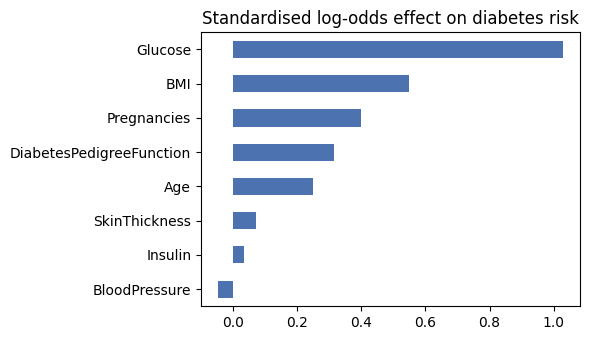

In [6]:
if best == "logistic regression":
    coefs = pd.Series(final[-1].coef_[0], index=X.columns).sort_values()
    coefs.plot.barh(color="#4C72B0", figsize=(6, 3.5)); plt.title("Standardised log-odds effect on diabetes risk")
else:
    from sklearn.inspection import permutation_importance
    imp = permutation_importance(final, X_test, y_test, scoring="roc_auc", n_repeats=20, random_state=SEED)
    pd.Series(imp.importances_mean, index=X.columns).sort_values().plot.barh(color="#4C72B0", figsize=(6, 3.5)); plt.title("Permutation importance (ROC-AUC drop)")
plt.tight_layout(); plt.savefig("images/feature_effects.png", dpi=120); plt.show()